# SFR Fly Mean-Reversion — 7. Cross-sectional rank

**Formulation: rank the flies against each other, not against their own past.**

This is the framework the prior work says should win. `FINDINGS_kink_fade.md`
(250 dates, 2025-05 → 2026-05, 44 flies) measured a within-gap cross-sectional
IC of the fly level against the forward change of **−0.27 (t = −8.3)** at
h = 21, with a naive long/short fade at IR ≈ **+1.35** and a non-overlapping
Sharpe of **+1.97** — while the options-implied signal added nothing. That was
one regime, one year, and gross of costs (`QueryDrivenBacktest` charges
`fee = 0.0`). This notebook re-runs it on 4.6 and 7.6 years, with costs.

Two accountings are reported side by side, because they are not the same claim:

* **`ls_fade`** — the prior-art function reproduced faithfully: daily
  cross-sectional terciles, forward Δfly at horizon `h`, cost charged *per
  date*, IR annualised, plus the non-overlapping Sharpe. This is the number
  comparable to the prior verdict.
* **the engine** — discrete trades with lag-1 fills, a round trip charged once
  per completed trade, and the same verdict machinery as every other framework.

Standardisation is **within pack** (whites 1-4, reds 5-8, greens 9-12, blues
13-16). Pooling raw levels across the strip would rank maturity, not richness:
`SFR123` has a 15.7bp standard deviation and `SFR-14-15-16` has 0.5bp.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    horizons=(5, 21, 63),
    frac=0.33,
    xs_windows=(0, 60, 120),         # 0 = rank the RAW LEVEL (the prior art)
    methods=("zscore", "rank"),
    entry_zs=(0.8, 1.2, 1.6),
    exits=("z0", "t5", "t21"),
    directions=("fade", "momentum"),
    max_hold=30,
    lag=1,
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'horizons': (5, 21, 63),
 'frac': 0.33,
 'xs_windows': (0, 60, 120),
 'methods': ('zscore', 'rank'),
 'entry_zs': (0.8, 1.2, 1.6),
 'exits': ('z0', 't5', 't21'),
 'directions': ('fade', 'momentum'),
 'max_hold': 30,
 'lag': 1}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import math

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.signals import xsection_signal
from sfr_fly_meanrev_common import load_lab, per_slot_table, run_family

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels, st = lab["levels"], lab["struct"]
packs = st.drop_duplicates("key").set_index("key")["pack"]
packs = packs.reindex(levels.columns)
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions")
print(f"packs: {packs.value_counts().to_dict()}")

34 flies, 1150 sessions
packs: {'blues': 17, 'reds': 7, 'whites': 6, 'greens': 4}


## 1. Prior-art functions, reproduced

`nw_t` and `ls_fade` are the versions from
`notebooks/backtests/SFR_screeners/kink_fade_backtest.py`, kept bug-for-bug so
the numbers are comparable: the Bartlett kernel uses population gammas, `ir`
mixes the overlapping mean with the non-overlapping standard deviation, and
`cost_bps` is charged as `2 * cost_bps` on **every date**.

In [3]:
def nw_t(x, lag):
    """Newey-West t-stat of the mean (kink_fade_backtest.py:124)."""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 3:
        return np.nan
    e = x - x.mean()
    var = (e @ e) / n
    for l in range(1, min(lag, n - 1) + 1):
        w = 1 - l / (lag + 1)
        var += 2 * w * (e[l:] @ e[:-l]) / n
    return x.mean() / (math.sqrt(var / n) + 1e-12)


def build_panel(levels, packs, horizons):
    """Long panel with forward changes, built on a per-key business-day ordinal
    so Delta at t+h is the SAME fixed-contract fly h sessions later."""
    frames = []
    for c in levels.columns:
        s = levels[c].dropna()
        d = pd.DataFrame({"date": s.index, "key": c, "fly": s.to_numpy(),
                          "pack": packs.get(c)})
        for h in horizons:
            d[f"dfly_{h}"] = s.shift(-h).to_numpy() - s.to_numpy()
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


def zwithin(df, col, by):
    g = df.groupby(by)[col]
    return (df[col] - g.transform("mean")) / (g.transform("std") + 1e-12)


def xs_ic(panel, sig, h, within=True):
    rows = []
    for d, g in panel.dropna(subset=[sig, f"dfly_{h}"]).groupby("date"):
        if within:
            vals = []
            for _, gg in g.groupby("pack"):
                if len(gg) >= 3 and gg[sig].nunique() >= 3:
                    vals.append(gg[[sig, f"dfly_{h}"]].corr(method="spearman").iloc[0, 1])
            if vals:
                rows.append(np.mean(vals))
        else:
            if len(g) >= 5 and g[sig].nunique() >= 5:
                rows.append(g[[sig, f"dfly_{h}"]].corr(method="spearman").iloc[0, 1])
    a = np.asarray(rows, float)
    a = a[np.isfinite(a)]
    if a.size < 3:
        return {}
    return {"IC": a.mean(), "t": a.mean() / (a.std(ddof=1) + 1e-12) * math.sqrt(a.size),
            "n_dates": a.size, "hit": float((a < 0).mean())}


def ls_fade(panel, sig, h, frac=0.33, within_pack=True, cost_bps=0.0):
    """Daily cross-sectional fade: short the top-frac signal, long the bottom."""
    df = panel.dropna(subset=[sig, f"dfly_{h}"]).copy()

    def one_book(g):
        if len(g) < 3 or g[sig].nunique() < 3:
            return None
        k = max(1, int(len(g) * frac))
        order = g[sig].rank(method="first")
        longs, shorts = g[order <= k], g[order > len(g) - k]
        return (longs[f"dfly_{h}"].mean() - shorts[f"dfly_{h}"].mean())

    recs = []
    for d, g in df.groupby("date"):
        if within_pack:
            books = [b for b in (one_book(gg) for _, gg in g.groupby("pack"))
                     if b is not None]
            if not books:
                continue
            pnl = float(np.mean(books))
        else:
            pnl = one_book(g)
            if pnl is None:
                continue
        recs.append({"date": d, "pnl": pnl - cost_bps * 2.0})
    if len(recs) < 3:
        return None
    s = pd.DataFrame(recs).set_index("date").sort_index()
    ppy = 252.0 / h
    nonover = s.iloc[::h]
    mean = s["pnl"].mean()
    sd = nonover["pnl"].std(ddof=1) if len(nonover) > 2 else s["pnl"].std(ddof=1)
    cum = s["pnl"].cumsum()
    return {"series": s, "n": len(s), "mean": mean,
            "ir": mean * ppy / (sd * math.sqrt(ppy) + 1e-12),
            "hit": float((s["pnl"] > 0).mean()),
            "maxdd": float((cum - cum.cummax()).min()),
            "nonover": (float(nonover["pnl"].mean() / (nonover["pnl"].std(ddof=1) + 1e-12)
                              * math.sqrt(ppy)) if len(nonover) > 2 else np.nan),
            "nw_t": nw_t(s["pnl"].to_numpy(), h)}


panel = build_panel(levels, packs, CONFIG["horizons"])
print(f"panel {panel.shape}, {panel['date'].nunique()} dates")

panel (16092, 7), 1150 dates


## 2. Does the fly level predict its own forward change?

The prior verdict to reproduce: within-gap IC of −0.27 (t = −8.3) at h = 21.

In [4]:
rows = []
for h in CONFIG["horizons"]:
    r = xs_ic(panel, "fly", h, within=True)
    if r:
        rows.append({"h": h, "scope": "within pack", **r})
    r = xs_ic(panel, "fly", h, within=False)
    if r:
        rows.append({"h": h, "scope": "pooled", **r})
ic = pd.DataFrame(rows)
print("cross-sectional IC of the fly LEVEL vs its forward change:")
print(ic.round(4).to_string(index=False))
print("\n  a NEGATIVE IC is mean reversion: a rich fly subsequently falls.")

cross-sectional IC of the fly LEVEL vs its forward change:
 h       scope      IC        t  n_dates    hit
 5 within pack -0.1344 -12.0884     1144 0.6276
 5      pooled -0.0893  -7.8913     1144 0.5857
21 within pack -0.1302 -10.5028     1128 0.6046
21      pooled -0.0594  -4.7600     1128 0.5691
63 within pack -0.1855 -14.1439     1087 0.6320
63      pooled -0.1407 -10.5394     1086 0.6308

  a NEGATIVE IC is mean reversion: a rich fly subsequently falls.


## 3. `ls_fade` — the prior-art long/short book, with and without costs

`cost_bps` is per side per date in this accounting, so `0.75` is the 1.5bp
package round trip charged on every date the book is held.

In [5]:
rows = []
for h in CONFIG["horizons"]:
    for cost in (0.0, 0.25, 0.75):
        r = ls_fade(panel, "fly", h, frac=CONFIG["frac"], cost_bps=cost)
        if r is None:
            continue
        rows.append({"h": h, "cost_bps_per_side": cost, "n_dates": r["n"],
                     "mean_bp": r["mean"], "IR": r["ir"], "hit": r["hit"],
                     "maxdd_bp": r["maxdd"], "nonover_sharpe": r["nonover"],
                     "nw_t": r["nw_t"]})
lsf = pd.DataFrame(rows)
print(lsf.round(3).to_string(index=False))
print("\n  IR at cost 0 is the prior-art comparable; the 0.75 row is the honest one.")

 h  cost_bps_per_side  n_dates  mean_bp     IR   hit  maxdd_bp  nonover_sharpe    nw_t
 5               0.00     1145    0.288  1.159 0.583   -53.708           1.243   3.299
 5               0.25     1145   -0.212 -0.855 0.405  -243.937          -0.770  -2.432
 5               0.75     1145   -1.212 -4.882 0.158 -1386.646          -4.797 -13.894
21               0.00     1129    0.659  0.750 0.583  -212.250           0.610   2.245
21               0.25     1129    0.159  0.181 0.482  -256.583           0.041   0.543
21               0.75     1129   -0.841 -0.956 0.318 -1034.437          -1.096  -2.863
63               0.00     1087    1.319  0.700 0.638  -286.958           1.281   2.149
63               0.25     1087    0.819  0.434 0.576  -327.958           1.016   1.334
63               0.75     1087   -0.181 -0.096 0.456  -722.000           0.485  -0.295

  IR at cost 0 is the prior-art comparable; the 0.75 row is the honest one.


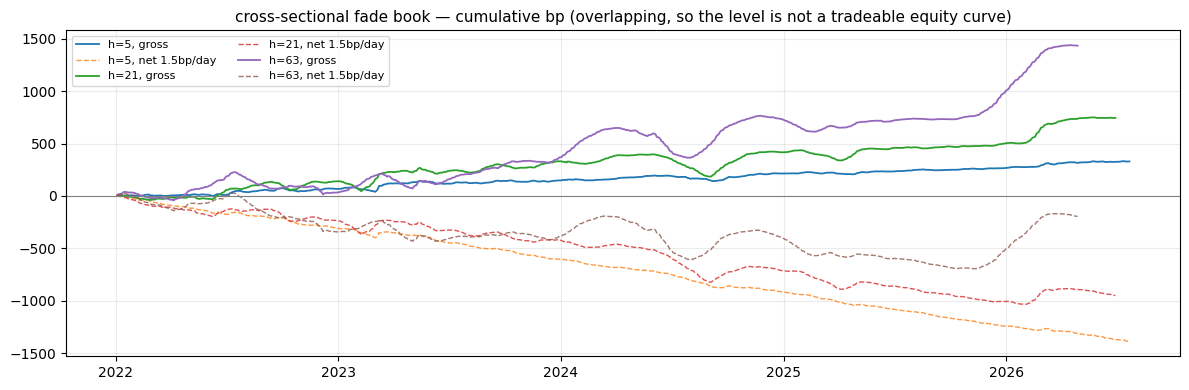

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
for h in CONFIG["horizons"]:
    r = ls_fade(panel, "fly", h, frac=CONFIG["frac"], cost_bps=0.0)
    if r is None:
        continue
    ax.plot(r["series"].index, r["series"]["pnl"].cumsum().to_numpy(), lw=1.3,
            label=f"h={h}, gross")
    r2 = ls_fade(panel, "fly", h, frac=CONFIG["frac"], cost_bps=0.75)
    if r2 is not None:
        ax.plot(r2["series"].index, r2["series"]["pnl"].cumsum().to_numpy(),
                lw=1.0, ls="--", alpha=0.8, label=f"h={h}, net 1.5bp/day")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("cross-sectional fade book — cumulative bp (overlapping, so the "
             "level is not a tradeable equity curve)", fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4. Regime split of the cross-sectional book

The prior work covered one mild-easing year. This is the same book across four
policy regimes.

In [7]:
reg = lab["regimes"]
rows = []
for h in CONFIG["horizons"]:
    r = ls_fade(panel, "fly", h, frac=CONFIG["frac"], cost_bps=0.0)
    if r is None:
        continue
    s = r["series"]["pnl"]
    rr = reg.reindex(s.index).ffill()
    for name in ["ZIRP", "HIKING", "PLATEAU", "CUTTING"]:
        sub = s[rr == name]
        if len(sub) < 20:
            continue
        ppy = 252.0 / h
        non = sub.iloc[::h]
        sd = non.std(ddof=1) if len(non) > 2 else sub.std(ddof=1)
        rows.append({"h": h, "regime": name, "n_dates": len(sub),
                     "mean_bp": sub.mean(),
                     "IR": sub.mean() * ppy / (sd * math.sqrt(ppy) + 1e-12),
                     "hit": float((sub > 0).mean())})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 h  regime  n_dates  mean_bp     IR   hit
 5    ZIRP       51    0.098  0.833 0.608
 5  HIKING      342    0.362  1.062 0.544
 5 PLATEAU      288    0.066  0.350 0.562
 5 CUTTING      464    0.391  2.411 0.621
21    ZIRP       51   -0.498 -1.502 0.451
21  HIKING      342    0.763  0.839 0.582
21 PLATEAU      288    0.048  0.053 0.497
21 CUTTING      448    1.105  1.134 0.654
63    ZIRP       51   -0.206 -0.136 0.392
63  HIKING      342    0.628  0.303 0.588
63 PLATEAU      288    1.369  0.870 0.639
63 CUTTING      406    2.057  0.704 0.712


## 5. The same idea through the engine, with per-trade costs


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -744.62bp | IQR [-1124.38, -478.50] | 0% net-positive | best -106.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 xs_window method  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
         0 zscore      1.6         z0      fade       114     0.246      -0.934       -106.50      -266250.0  -0.793    -135.50
         0 zscore      1.6        t21      fade       137     0.241      -1.051       -144.00      -360000.0  -1.068    -161.50
         0   rank      1.6         z0      fade       156     0.160      -0.957       -149.25      -373125.0  -1.775    -157.00
         0   rank      1.6        t21      fade       170     0.100      -1.322       -224.75      -561875.0  -2.792    -226.75
         0 zscore      1.6         z0  momentum       114     0.175      -2.066       -235.50      -588750.0  -1.760    -235.50
         0 zscore      1.6        t21  momentum       137     0.182 

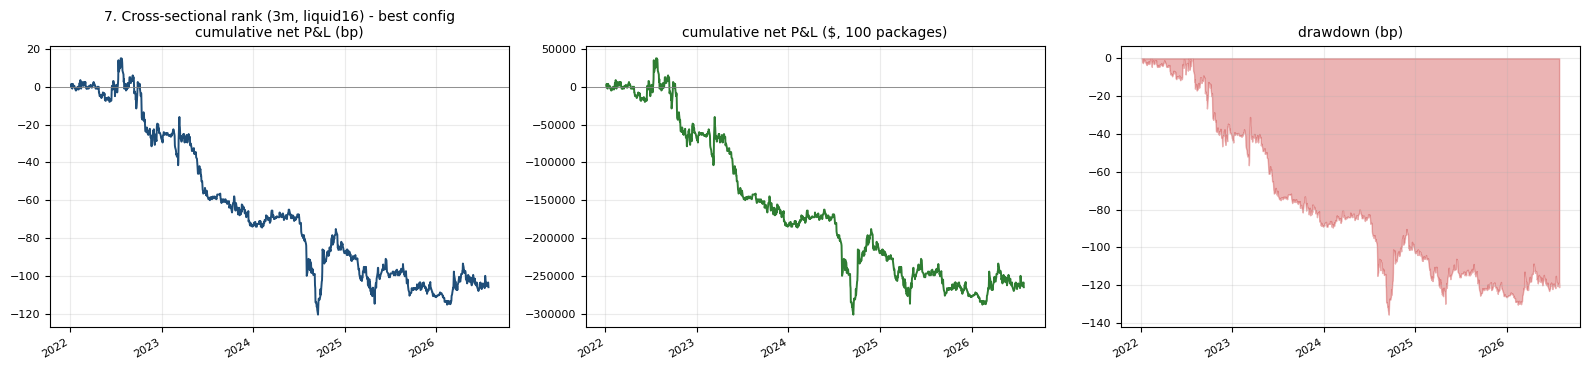


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
U24-Z24-H25   -1  2022-01-03 2022-01-04 2022-02-14    28  1.732       4.0        0.0       4.0      1.5     2.5   6250.0 mean_reversion
U23-Z23-H24   -1  2022-01-04 2022-01-05 2022-01-07     2  1.606       4.0        4.0      -0.0      1.5    -1.5  -3750.0 mean_reversion
M23-U23-Z23   -1  2022-01-07 2022-01-10 2022-01-13     3  1.604       5.5        3.5       2.0      1.5     0.5   1250.0 mean_reversion
U23-Z23-H24   -1  2022-01-12 2022-01-13 2022-01-19     3  1.606       5.0        4.5       0.5      1.5    -1.0  -2500.0 mean_reversion
M23-U23-Z23    1  2022-01-20 2022-01-21 2022-03-07    30 -1.677       2.5        4.5       2.0      1.5     0.5   1250.0       max_hold
U24-Z24-H25   -1  2022-02-28 2022-03-01 2022-04-12    30  1.652       2.5        3.0      -0.5      1.5    -2.0  -5000.0       max_hold
U25-Z25-H26   -1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       114    25.789     0.246      -0.934       -106.50  -0.793
half       115    23.783     0.243      -1.033       -118.75  -0.896
band       115    23.783     0.243      -1.033       -118.75  -0.896
  t5       328     4.982     0.140      -1.389       -455.75  -4.192
 t10       223     9.879     0.179      -1.191       -265.50  -2.166
 t20       138    19.572     0.239      -1.266       -174.75  -1.304

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 114          64.5       0.566     0.553       161250.0
           0.5 114           7.5       0.066     0.404        18750.0
           1.0 114         -49.5      -0.434     0.298      -123750.0
           1.5 114        -106.5      -0.934     0.246      -266250.0
           2.5 114        -220.5      -1.934     0.211      -551250.0
           4.0 114        -391.5      -3.43

7. Cross-sectional rank (3m, liquid16) - MEDIAN config (the anti-selection control)  |  fade|z1.2|z0|hold30|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   582   skipped    0   hit 10%   avg -1.276bp   avg hold 13.1d
  total    -742.50bp   $   -1,856,250   gross +130.50bp
  daily-MTM Sharpe -3.69   maxDD -742.50bp ($-1,856,250)   worst trade -31.50bp
  t(trade) -10.93   NW t(daily) -9.59   non-overlap SR -0.26   DSR p=0.000 over 108 trials

  LEAGUE ROW  7. Cross-sectional rank (3m, liquid16) / best-config: MARGINAL-maker-only  (taker -220.50bp, maker +64.50bp, DSR p=0.000)

  LEAGUE ROW  7. Cross-sectional rank (3m, liquid16) / median-config: MARGINAL-maker-only  (taker -1324.50bp, maker +130.50bp, DSR p=0.000)


In [8]:
def xs_sig(L, xs_window, method):
    return xsection_signal(L, groups=packs, method=method, window=xs_window,
                           min_names=3)


GRID = {"xs_window": CONFIG["xs_windows"], "method": CONFIG["methods"],
        "entry_z": CONFIG["entry_zs"], "exit_style": CONFIG["exits"],
        "direction": CONFIG["directions"]}
PARAMS = ["xs_window", "method", "entry_z", "exit_style", "direction"]
out = run_family("7. Cross-sectional rank (3m, liquid16)", lab=lab,
                 signal_fn=xs_sig, grid_spec=GRID, params=PARAMS, base=BASE,
                 cls="xsection",
                 note="within-pack standardisation, then pooled; per-trade costs")

In [9]:
per = per_slot_table(out["result"], lab)
if not per.empty:
    print(per.round(3).to_string(index=False))

 slot           cm  n   hit  avg_net_bp  total_net_bp  total_gross_bp  avg_hold  total_net_usd
  2.0       SFR123 15 0.467       0.967          14.5            37.0    19.000        36250.0
  3.0       SFR234 16 0.375      -0.750         -12.0            12.0    29.312       -30000.0
  4.0       SFR345 15 0.200      -2.400         -36.0           -13.5    28.333       -90000.0
  5.0       SFR456 10 0.300      -0.600          -6.0             9.0    26.500       -15000.0
  6.0       SFR567  7 0.286      -0.929          -6.5             4.0    30.000       -16250.0
  7.0       SFR678 14 0.214      -1.893         -26.5            -5.5    26.643       -66250.0
  8.0       SFR789  9 0.000      -1.889         -17.0            -3.5    23.889       -42500.0
  9.0   SFR-8-9-10  2 0.500      -1.000          -2.0             1.0    19.000        -5000.0
 10.0  SFR-9-10-11  5 0.400      -0.100          -0.5             7.0    29.600        -1250.0
 11.0 SFR-10-11-12  3 0.000      -1.000          -

## 6. Long window — the sample-composition test

In [10]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
packs8 = (lab8["struct"].drop_duplicates("key").set_index("key")["pack"]
          .reindex(lab8["levels"].columns))
panel8 = build_panel(lab8["levels"], packs8, CONFIG["horizons"])
rows = []
for h in CONFIG["horizons"]:
    for cost in (0.0, 0.75):
        r = ls_fade(panel8, "fly", h, frac=CONFIG["frac"], cost_bps=cost)
        if r is None:
            continue
        rows.append({"h": h, "cost_bps_per_side": cost, "n_dates": r["n"],
                     "mean_bp": r["mean"], "IR": r["ir"],
                     "nonover_sharpe": r["nonover"], "nw_t": r["nw_t"]})
print("ls_fade on the 2019+ front-8 panel:")
print(pd.DataFrame(rows).round(3).to_string(index=False))

ls_fade on the 2019+ front-8 panel:
 h  cost_bps_per_side  n_dates  mean_bp     IR  nonover_sharpe   nw_t
 5               0.00     1901    0.279  0.527           0.476  1.793
 5               0.75     1901   -1.221 -2.309          -2.360 -7.861
21               0.00     1884    0.810  0.457           0.456  1.614
21               0.75     1884   -0.690 -0.390          -0.391 -1.374
63               0.00     1839    2.092  0.641           0.628  2.292
63               0.75     1839    0.592  0.181           0.168  0.649


In [11]:
out8 = run_family("7b. Cross-sectional rank (3m, front8, 2019+)", lab=lab8,
                  signal_fn=lambda L, xs_window, method: xsection_signal(
                      L, groups=packs8, method=method, window=xs_window,
                      min_names=3),
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="xsection",
                  note="long history")


### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -524.62bp | IQR [-888.62, -292.12] | 0% net-positive | best +0.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 xs_window method  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
         0   rank      1.6        t21      fade         0       NaN         NaN           0.0            0.0     NaN        0.0
         0   rank      1.6        t21  momentum         0       NaN         NaN           0.0            0.0     NaN        0.0
         0   rank      1.6         t5  momentum         0       NaN         NaN           0.0            0.0     NaN        0.0
         0   rank      1.6         t5      fade         0       NaN         NaN           0.0            0.0     NaN        0.0
         0   rank      1.6         z0  momentum         0       NaN         NaN           0.0            0.0     NaN        0.0
         0   rank      1.6         z0      fade         0       NaN    

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0         0       NaN       NaN         NaN           0.0     NaN
half         0       NaN       NaN         NaN           0.0     NaN
band         0       NaN       NaN         NaN           0.0     NaN
  t5         0       NaN       NaN         NaN           0.0     NaN
 t10         0       NaN       NaN         NaN           0.0     NaN
 t20         0       NaN       NaN         NaN           0.0     NaN

LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5         0             0.0           0.0         NaN       NaN     NaN        0.0       NaN          False             False
         belly       1            0.5         0             0.0           0.0         NaN       NaN     NaN        0.0  

7b. Cross-sectional rank (3m, front8, 2019+) - MEDIAN config (the anti-selection control)  |  fade|z1.2|z0|hold30|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   442   skipped    2   hit 19%   avg -1.190bp   avg hold 12.4d
  total    -526.00bp   $   -1,315,000   gross +137.00bp
  daily-MTM Sharpe -2.06   maxDD -526.50bp ($-1,316,250)   worst trade -17.50bp
  t(trade) -8.04   NW t(daily) -7.00   non-overlap SR -0.43   DSR p=0.000 over 108 trials

  LEAGUE ROW  7b. Cross-sectional rank (3m, front8, 2019+) / best-config: DEAD (too few trades)  (taker +0.00bp, maker +0.00bp, DSR p=nan)

  LEAGUE ROW  7b. Cross-sectional rank (3m, front8, 2019+) / median-config: MARGINAL-maker-only  (taker -968.00bp, maker +137.00bp, DSR p=0.000)


## 7. 6m flies


### GRID  (32 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -580.00bp | IQR [-836.50, -336.44] | 0% net-positive | best -47.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 xs_window method  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
         0   rank      1.6         z0      fade       107     0.262      -0.442        -47.25      -118125.0  -0.266    -162.75
         0 zscore      1.6         z0  momentum        71     0.366      -0.870        -61.75      -154375.0  -0.201    -182.50
         0 zscore      1.6        t21  momentum        94     0.372      -1.045        -98.25      -245625.0  -0.338    -234.75
         0   rank      1.6        t21      fade       131     0.244      -0.849       -111.25      -278125.0  -0.732    -160.75
         0   rank      1.2         z0      fade       149     0.289      -0.763       -113.75      -284375.0  -0.471    -171.75
       120 zscore      1.6        t21  momentum       165     0.248   

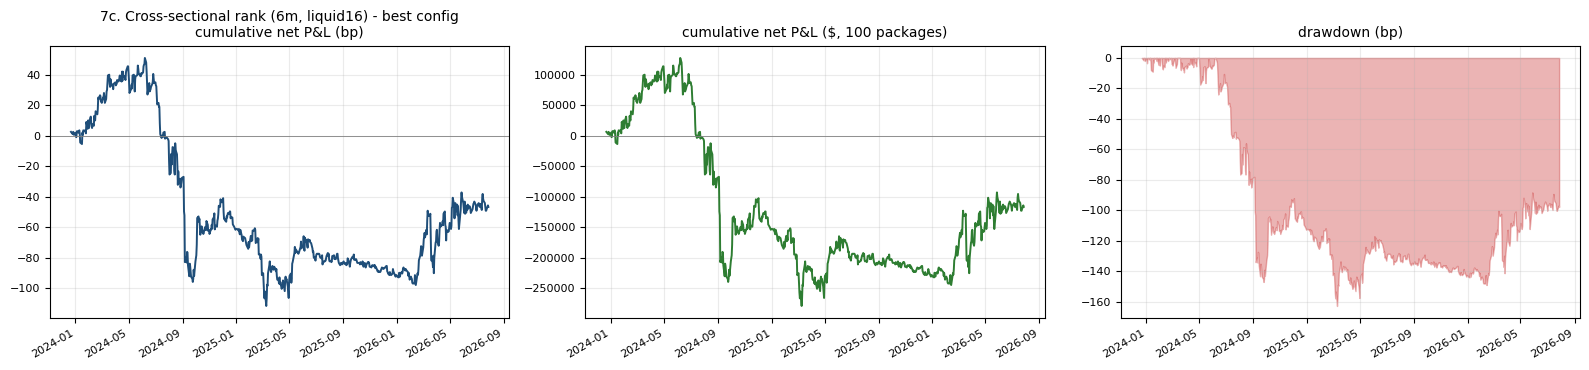


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
Z24-M25-Z25    1  2023-12-20 2023-12-21 2024-02-06    30 -1.645     -36.5      -33.0       3.5      1.5     2.0   5000.0       max_hold
Z25-M26-Z26   -1  2023-12-20 2023-12-21 2024-02-06    30  1.645      -0.5       -1.5       1.0      1.5    -0.5  -1250.0       max_hold
H26-U26-H27   -1  2023-12-21 2023-12-22 2024-02-07    30  1.645       0.5        1.5      -1.0      1.5    -2.5  -6250.0       max_hold
Z26-M27-Z27   -1  2023-12-26 2023-12-27 2024-02-09    30  1.645      -1.5       -1.0      -0.5      1.5    -2.0  -5000.0       max_hold
U24-H25-U25    1  2024-01-11 2024-01-12 2024-02-27    30 -1.645     -38.0      -19.0      19.0      1.5    17.5  43750.0       max_hold
Z24-M25-Z25    1  2024-02-07 2024-02-08 2024-03-22    30 -1.645     -31.5      -20.5      11.0      1.5     9.5  23750.0       max_hold
H26-U26-H27   -1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       107    26.290     0.262      -0.442        -47.25  -0.266
half       136    16.434     0.213      -0.774       -105.25  -0.633
band       136    16.434     0.213      -0.774       -105.25  -0.633
  t5       299     4.970     0.187      -1.226       -366.50  -2.869
 t10       205     9.873     0.229      -1.089       -223.25  -1.608
 t20       135    19.696     0.237      -0.976       -131.75  -0.871

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 107        113.25       1.058     0.561       283125.0
           0.5 107         59.75       0.558     0.439       149375.0
           1.0 107          6.25       0.058     0.346        15625.0
           1.5 107        -47.25      -0.442     0.262      -118125.0
           2.5 107       -154.25      -1.442     0.206      -385625.0
           4.0 107       -314.75      -2.94

7c. Cross-sectional rank (6m, liquid16) - MEDIAN config (the anti-selection control)  |  fade|z1.2|t5|hold30|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   446   skipped    2   hit 17%   avg -1.305bp   avg hold 5.0d
  total    -582.00bp   $   -1,455,000   gross +87.00bp
  daily-MTM Sharpe -3.33   maxDD -586.00bp ($-1,465,000)   worst trade -21.00bp
  t(trade) -7.24   NW t(daily) -6.81   non-overlap SR -0.35   DSR p=0.000 over 108 trials

  LEAGUE ROW  7c. Cross-sectional rank (6m, liquid16) / best-config: MARGINAL-maker-only  (taker -154.25bp, maker +113.25bp, DSR p=0.000)

  LEAGUE ROW  7c. Cross-sectional rank (6m, liquid16) / median-config: MARGINAL-maker-only  (taker -1028.00bp, maker +87.00bp, DSR p=0.000)


In [12]:
lab6 = load_lab("6m", CONFIG["primary_window"])
packs6 = (lab6["struct"].drop_duplicates("key").set_index("key")["pack"]
          .reindex(lab6["levels"].columns))
out6 = run_family("7c. Cross-sectional rank (6m, liquid16)", lab=lab6,
                  signal_fn=lambda L, xs_window, method: xsection_signal(
                      L, groups=packs6, method=method, window=xs_window,
                      min_names=3),
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="xsection",
                  note="6m flies")